In [ ]:
#conda activate pathformer
import deepmimo as dm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
scenario = 'city_91_xiangyang_3p5'
scenario = 'city_47_chicago_3p5'

# Download a Scenario
dm.download(scenario)

# Load to memory
dataset = dm.load(scenario)
plot_dataset = dataset[0] if hasattr(dataset, 'datasets') else dataset

def _as_pos_2d(values):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        return values.reshape(1, -1)
    return values.reshape(-1, values.shape[-1])

def plot_rays_safe(ds, user_idx, ax=None, proj_3D=True, title=None):
    ax = dm.plot_rays(
        _as_pos_2d(ds.rx_pos)[user_idx],
        _as_pos_2d(ds.tx_pos)[0],
        np.asarray(ds.inter_pos)[user_idx],
        np.asarray(ds.inter)[user_idx],
        ax=ax,
        proj_3D=proj_3D,
    )
    if title is not None:
        ax.set_title(title)
    return ax

def plot_multipath_on_scene(user_idx, ds=None, title=None):
    ds = plot_dataset if ds is None else ds
    ax = ds.scene.plot(title=False, proj_3D=False)
    plot_rays_safe(ds, user_idx, ax=ax, proj_3D=False)
    ax.set_title(title or f"User {user_idx}: multipath over environment")
    plt.tight_layout()
    return ax


Scenario "city_91_xiangyang_3p5" already exists in /home/blessedg/Pathformer/deepmimo_scenarios
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 94697)
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 94697)
Loading TXRX PAIR: TXset 3 (tx_idx 0) & RXset 0 (rx_idxs 94697)


<Axes3D: title={'center': 'Buildings: 36, Terrain: 1'}, xlabel='X (m)', ylabel='Y (m)', zlabel='Z (m)'>

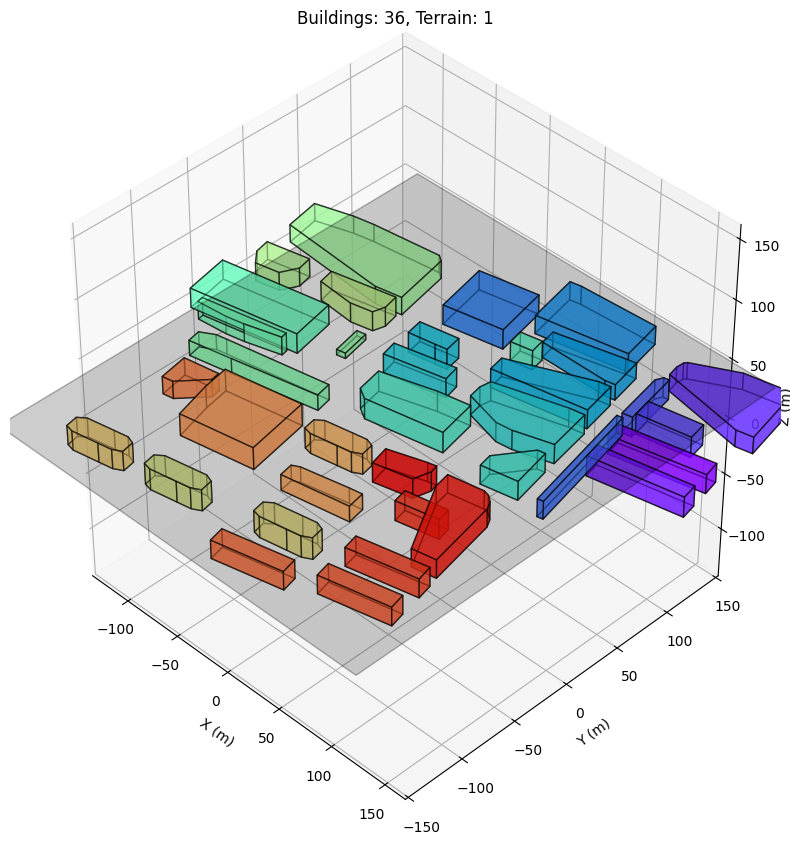

In [18]:
plot_dataset.scene.plot()

<Axes: title={'center': 'User 50744: multipath over environment'}, xlabel='x (m)', ylabel='y (m)'>

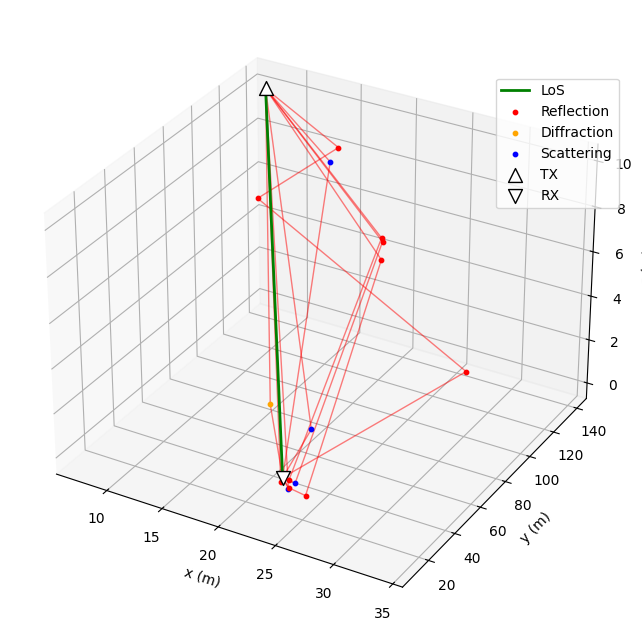

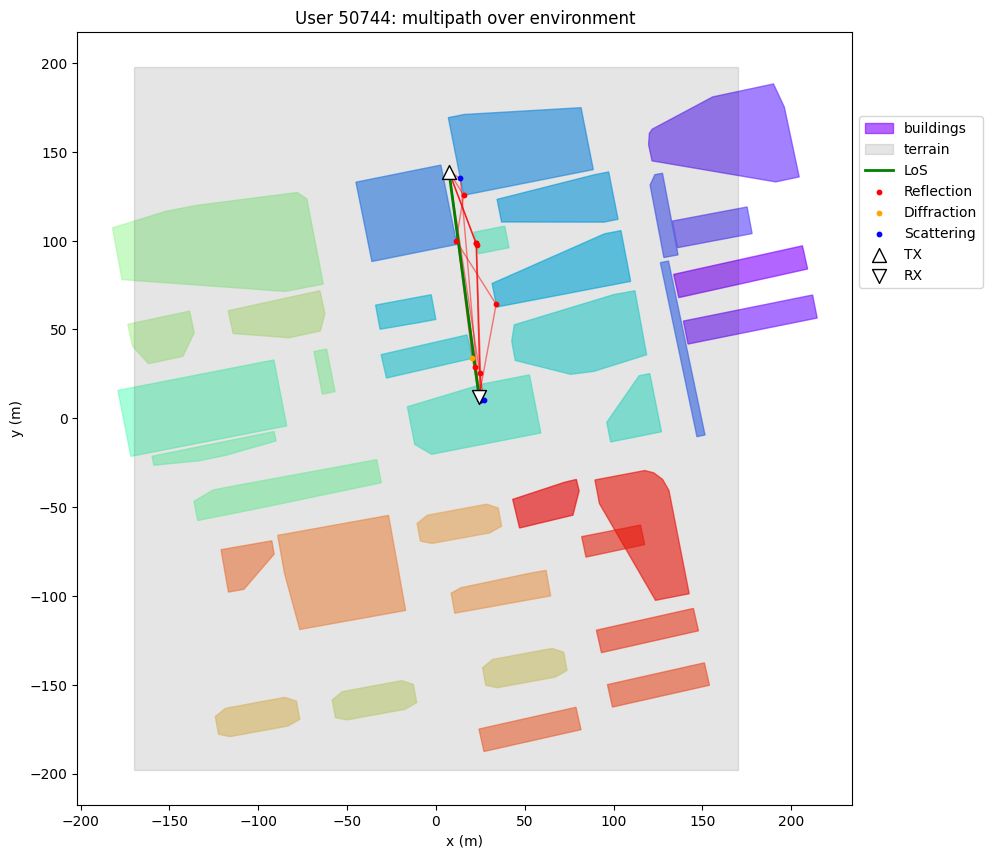

In [2]:
# Plot ray paths for a user in line of sight
los_user = np.where(plot_dataset.los == 1)[0][0]
plot_rays_safe(plot_dataset, los_user)
plot_multipath_on_scene(los_user)

In [ ]:
# Plot ray paths for a user in line of sight
los_user = np.where(plot_dataset.los == 1)[0][390]
plot_rays_safe(plot_dataset, los_user)
plot_multipath_on_scene(los_user)

In [ ]:
los_user

In [ ]:
# Plot ray paths for a user in line of sight
los_user = np.where(plot_dataset.los == 1)[0][390]
plot_rays_safe(plot_dataset, los_user)
plot_multipath_on_scene(los_user)

(<Axes: xlabel='x (m)', ylabel='y (m)'>,
 <matplotlib.colorbar.Colorbar at 0x155433a53730>)

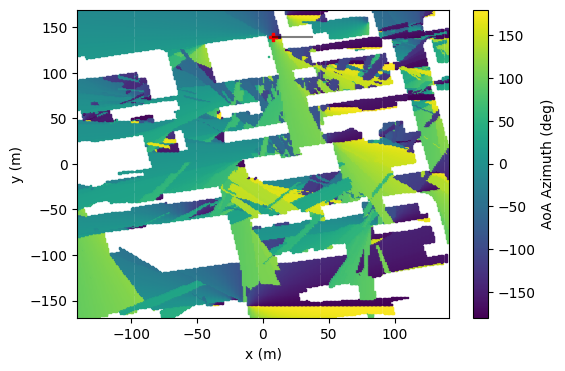

In [24]:
# Plot power coverage map (power is [n_ue, n_paths])
# plot_dataset.power.plot() # selects first path by default

plot_dataset.aoa_az.plot() # selects first path by default


In [ ]:
dataset.info()

In [ ]:
dm.info()

In [ ]:
all_scenarios = [
    # 'city_10_florida_villa_7gp_1758095156175',
    # 'city_74_chiyoda_3p5',

    'city_0_newyork_3p5_s',
    'city_1_losangeles_3p5',
    'city_2_chicago_3p5',
    'city_3_houston_3p5',
    'city_4_phoenix_3p5',
    'city_5_philadelphia_3p5',
    'city_6_miami_3p5',
    'city_7_sandiego_3p5',
    'city_8_dallas_3p5',
    'city_9_sanfrancisco_3p5',
    'city_10_austin_3p5',
    'city_11_santaclara_3p5',
    'city_12_fortworth_3p5',
    'city_13_columbus_3p5',
    'city_17_seattle_3p5_s',
    'city_18_denver_3p5',
    'city_19_oklahoma_3p5_s',
    'city_16_sanfrancisco_3p5_lwm',
    'city_23_beijing_3p5',
    'city_31_barcelona_3p5',
    'city_35_san_francisco_3p5',
    'city_47_chicago_3p5',
    'city_89_nairobi_3p5',
    'city_91_xiangyang_3p5',
    'city_92_sãopaulo_3p5',
    'boston5g_3p5',
    'city_86_ankara_3p5',
    'city_72_capetown_3p5',
    'city_84_baoding_3p5',
    'city_95_delhi_3p5',
    'city_96_osaka_3p5',
    'city_88_tongshan_3p5'
]
print(len(all_scenarios))
output_csv = 'scenario_dataset_description.csv'

In [ ]:
from pathlib import Path

import pandas as pd


def _safe_mean(values):
    values = np.asarray(values, dtype=float).reshape(-1)
    values = values[np.isfinite(values)]
    return float(values.mean()) if values.size else np.nan


def _safe_max(values):
    values = np.asarray(values, dtype=float).reshape(-1)
    values = values[np.isfinite(values)]
    return float(values.max()) if values.size else np.nan


def _as_pos_2d(values):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        return values.reshape(1, -1)
    return values.reshape(-1, values.shape[-1])


def _scenario_summary_row(scenario_name):
    dm.download(scenario_name)
    loaded = dm.load(scenario_name)
    datasets = loaded if isinstance(loaded, list) else [loaded]

    scene = datasets[0].scene
    scene_bbox = scene.bounding_box
    label_counts = scene.count_objects_by_label()
    building_objects = list(scene.get_objects(label='buildings'))
    building_heights = np.array([obj.height for obj in building_objects], dtype=float) if building_objects else np.array([])

    all_rx_pos = np.vstack([_as_pos_2d(ds.rx_pos) for ds in datasets])
    all_tx_pos = np.vstack([_as_pos_2d(ds.tx_pos) for ds in datasets])
    all_num_paths = np.concatenate([np.asarray(ds.num_paths).reshape(-1) for ds in datasets])
    all_los = np.concatenate([np.asarray(ds.los).reshape(-1) for ds in datasets])
    all_geom_distance = np.concatenate([
        np.linalg.norm(_as_pos_2d(ds.rx_pos) - _as_pos_2d(ds.tx_pos)[0], axis=1)
        for ds in datasets
    ])
    all_pathloss = np.concatenate([np.asarray(ds.pathloss).reshape(-1) for ds in datasets])

    active_mask = all_num_paths > 0
    rx_min = all_rx_pos.min(axis=0)
    rx_max = all_rx_pos.max(axis=0)
    rx_width = float(rx_max[0] - rx_min[0])
    rx_length = float(rx_max[1] - rx_min[1])
    rx_height = float(rx_max[2] - rx_min[2])
    rx_area = float(rx_width * rx_length)
    scene_area = float(scene_bbox.width * scene_bbox.length)
    scene_volume = float(scene_bbox.width * scene_bbox.length * scene_bbox.height)
    active_users = int(active_mask.sum())

    return {
        'scenario': scenario_name,
        'num_tx_views': int(len(datasets)),
        'num_unique_tx_positions': int(np.unique(np.round(all_tx_pos, decimals=3), axis=0).shape[0]),
        'num_rx_total': int(all_rx_pos.shape[0]),
        'num_active_users': active_users,
        'active_user_ratio': float(active_users / all_rx_pos.shape[0]) if all_rx_pos.shape[0] else np.nan,
        'num_los_users': int(np.sum(all_los == 1)),
        'los_user_ratio': float(np.mean(all_los == 1)) if all_los.size else np.nan,
        'num_nlos_users': int(np.sum(all_los == 0)),
        'nlos_user_ratio': float(np.mean(all_los == 0)) if all_los.size else np.nan,
        'num_no_path_users': int(np.sum(all_los == -1)),
        'mean_num_paths_per_user': _safe_mean(all_num_paths),
        'mean_num_paths_active_user': _safe_mean(all_num_paths[active_mask]),
        'max_num_paths_user': _safe_max(all_num_paths),
        'mean_tx_rx_distance_m': _safe_mean(all_geom_distance),
        'mean_pathloss_db': _safe_mean(all_pathloss),
        'scene_num_objects': int(len(scene.objects)),
        'num_buildings': int(label_counts.get('buildings', 0)),
        'num_terrain': int(label_counts.get('terrain', 0)),
        'num_vegetation': int(label_counts.get('vegetation', 0)),
        'num_floorplans': int(label_counts.get('floorplans', 0)),
        'num_other_objects': int(label_counts.get('objects', 0)),
        'scene_width_m': float(scene_bbox.width),
        'scene_length_m': float(scene_bbox.length),
        'scene_height_m': float(scene_bbox.height),
        'scene_area_m2': scene_area,
        'scene_volume_m3': scene_volume,
        'building_density_per_km2': float(label_counts.get('buildings', 0) / scene_area * 1e6) if scene_area > 0 else np.nan,
        'mean_building_height_m': _safe_mean(building_heights),
        'max_building_height_m': _safe_max(building_heights),
        'tx_height_mean_m': _safe_mean(all_tx_pos[:, 2]),
        'rx_height_mean_m': _safe_mean(all_rx_pos[:, 2]),
        'rx_width_m': rx_width,
        'rx_length_m': rx_length,
        'rx_height_span_m': rx_height,
        'rx_area_m2': rx_area,
        'active_user_density_per_km2': float(active_users / rx_area * 1e6) if rx_area > 0 else np.nan,
    }


scenario_rows = [_scenario_summary_row(scenario) for scenario in all_scenarios]
scenario_stats_df = pd.DataFrame(scenario_rows).sort_values('scenario').reset_index(drop=True)
scenario_stats_df = scenario_stats_df.round(3)

output_path = Path(output_csv)
scenario_stats_df.to_csv(output_path, index=False)
print(f'Saved scenario statistics to {output_path.resolve()}')
scenario_stats_df